# Functional Connectivity Analysis: Low vs High Anhedonia

This notebook computes empirical **functional connectivity (FC)** matrices from the raw BOLD time series and compares LOW vs HIGH anhedonia groups across:
1. Whole-brain edge-wise FC (Wilcoxon + FDR)
2. Network-level FC (8×8: Yeo 7 + Subcortex)
3. Reward circuit FC (Pizzagalli 2022 regions)
4. Covariate-adjusted OLS regressions (Age, Sex, Patient/HC, Dx)

**Parcellation:** Schaefer-200 + Tian S2 = 232 regions  
**BOLD data:** 232 ROIs × 1952 timepoints per subject  
**Groups:** LOW (N=139), HIGH (N=71)

Companion to `payman_post_analyses_CLEAN.ipynb` (effective connectivity / trophic coherence analyses).

## Imports

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests
from scipy.signal import detrend, butter, filtfilt


## Data Loading

Load BOLD time series from the anhedonia grouping `.mat` files.  
Each file contains an object array of shape `(N_subjects, 2)` where:
- Column 0: BOLD array of shape `(232, 1952)` — 232 ROIs × 1952 timepoints
- Column 1: Subject ID string

In [ ]:
# %% Load BOLD data
mat_low  = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/NEW_4_factor_clustering_ipnybV4/low_anhedonia.mat')
mat_high = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/NEW_4_factor_clustering_ipnybV4/high_anhedonia.mat')

# mat_low  = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/_archived/shaps_only_anhedonia_clusters/low_anhedonia.mat')
# mat_high = sio.loadmat('/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/anhedonia/_archived/shaps_only_anhedonia_clusters/high_anhedonia.mat')


N_LOW  = mat_low['low_anhedonia'].shape[0]   # 139
N_HIGH = mat_high['high_anhedonia'].shape[0]  # 71

# Keep raw object arrays — subjects have slightly different n_timepoints,
# so we do NOT stack; FC is computed per-subject independently.
bold_low_raw  = [mat_low['low_anhedonia'][i, 0]  for i in range(N_LOW)]   # list of (232, T_i)
bold_high_raw = [mat_high['high_anhedonia'][i, 0] for i in range(N_HIGH)]  # list of (232, T_i)

# Subject IDs (for demographics merge)
ids_low  = [mat_low['low_anhedonia'][i, 1].flat[0]  for i in range(N_LOW)]
ids_high = [mat_high['high_anhedonia'][i, 1].flat[0] for i in range(N_HIGH)]

print(f'N_LOW={N_LOW}, N_HIGH={N_HIGH}')
from collections import Counter
print('LOW  timepoint lengths:', Counter(b.shape[1] for b in bold_low_raw))
print('HIGH timepoint lengths:', Counter(b.shape[1] for b in bold_high_raw))


N_LOW=139, N_HIGH=71
LOW  timepoint lengths: Counter({1952: 136, 1571: 1, 1650: 1, 1559: 1})
HIGH timepoint lengths: Counter({1952: 70, 1937: 1})


In [ ]:
mat_high['high_anhedonia']

array([[array([[10955.525066, 10854.486583, 10912.843074, ..., 12728.262678,
                12672.282883, 12659.088796],
               [12514.846436, 12468.236402, 12498.007931, ..., 11077.123559,
                10987.732081, 11121.896421],
               [12417.605136, 12294.282271, 12402.105025, ..., 11619.183512,
                11581.532656, 11649.591597],
               ...,
               [11086.575926, 11098.298292, 11090.418732, ..., 11224.390335,
                11204.415336, 11145.242165],
               [10614.336761, 10718.072061, 10700.362546, ..., 10793.868796,
                10773.654399, 10807.230111],
               [10732.399369, 10768.9294  , 10761.732477, ..., 10801.029685,
                10785.749384, 10801.749197]], shape=(232, 1952))            ,
        array(['NDAR_INVHZ510TB2'], dtype='<U16')],
       [array([[ 9322.800783,  9304.354411,  9279.867168, ..., 11851.247825,
                11813.045304, 11815.267601],
               [11257.348177, 11161.54315

In [ ]:
mat_high['high_anhedonia'][2][1].flat[0]

np.str_('NDAR_INVBL733HBP')

## Load Region Labels

232 ROI labels from Schaefer-200 + Tian S2 atlas.

In [ ]:
# %% Load region labels
label_file = '/Users/proghani/Documents/personal/code_experiments/neuro/phd_stuff/tcp_parcellations/data/atlases/Schaefer2018_200Parcels_7Networks_order_Tian_Subcortex_S2_label.txt'

with open(label_file, 'r') as f:
    lines = f.read().strip().splitlines()

region_labels = [lines[i] for i in range(0, len(lines), 2)]
assert len(region_labels) == 232, f'Expected 232 labels, got {len(region_labels)}'

print(region_labels[:5])    # subcortical (Tian S2)
print(region_labels[32:35]) # first cortical (Schaefer)

['aHIP-rh', 'pHIP-rh', 'lAMY-rh', 'mAMY-rh', 'THA-DP-rh']
['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3']


## Network and Reward ROI Definitions

Replicated from `payman_post_analyses_CLEAN.ipynb` for consistency.

In [ ]:
# %% Parse network membership
network_indices = {}
for i, label in enumerate(region_labels):
    net = 'Subcortex' if i < 32 else label.split('_')[2]
    network_indices.setdefault(net, []).append(i)

display_order = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default', 'Subcortex']

yeo_colors = {
    'Vis':         '#781286',
    'SomMot':      '#4682B4',
    'DorsAttn':    '#00760E',
    'SalVentAttn': '#C43AFA',
    'Limbic':      '#B8CF5E',
    'Cont':        '#E69422',
    'Default':     '#CD3E4E',
    'Subcortex':   '#808080',
}

for net in display_order:
    print(f'{net}: {len(network_indices[net])} regions')

Vis: 29 regions
SomMot: 35 regions
DorsAttn: 26 regions
SalVentAttn: 22 regions
Limbic: 12 regions
Cont: 30 regions
Default: 46 regions
Subcortex: 32 regions


In [ ]:
# %% Define reward circuit ROIs (Pizzagalli 2022)
reward_rois = {
    'NAc':        [8, 9, 24, 25],
    'Caudate':    [14, 15, 30, 31],
    'Putamen':    [12, 13, 28, 29],
    'OFC':        [i for i, l in enumerate(region_labels) if 'Limbic_OFC' in l or 'Cont_OFC' in l],
    'mPFC/vmPFC': [i for i, l in enumerate(region_labels) if ('Default_PFC' in l and 'pCun' not in l)],
    'ACC':        [i for i, l in enumerate(region_labels) if 'SalVentAttn_Med' in l or 'Cont_Cing' in l],
    'dlPFC':      [i for i, l in enumerate(region_labels) if 'Cont_PFCl' in l],
}
roi_order = ['NAc', 'Caudate', 'Putamen', 'OFC', 'mPFC/vmPFC', 'ACC', 'dlPFC']

for roi in roi_order:
    print(f'{roi} ({len(reward_rois[roi])} regions)')

NAc (4 regions)
Caudate (4 regions)
Putamen (4 regions)
OFC (6 regions)
mPFC/vmPFC (21 regions)
ACC (10 regions)
dlPFC (12 regions)


In [ ]:
# %% Preprocessing: Demean, Detrend, Bandpass Filter, Edge Trim
# Applied per-ROI before FC computation to match standard resting-state convention.
# Bandpass: 0.01–0.1 Hz (conventional for resting-state FC)
# TR = 0.8 s → Nyquist = 0.625 Hz

TR  = 0.8
flp = 0.01   # high-pass cutoff (Hz)
fhi = 0.1   # low-pass cutoff  (Hz) — conventional resting-state upper bound
fnq = 1 / (2 * TR)

Wn = [flp / fnq, fhi / fnq]
b_filt, a_filt = butter(2, Wn, btype='band')

def preprocess_bold(bold):
    """
    bold: (N_rois, N_timepoints)
    Returns preprocessed bold of shape (N_rois, N_timepoints - 20)
    """
    bold = bold.copy().astype(float)
    # 1. Demean + Detrend per ROI
    bold = detrend(bold - bold.mean(axis=1, keepdims=True), axis=1)
    # 2. Bandpass filter (zero-phase)
    bold = filtfilt(b_filt, a_filt, bold, axis=1)
    # 3. Trim edge artifacts (first/last 10 timepoints)
    bold = bold[:, 10:-10]
    return bold

print('Preprocessing BOLD — LOW group...')
bold_low_proc  = [preprocess_bold(b) for b in bold_low_raw]
print('Preprocessing BOLD — HIGH group...')
bold_high_proc = [preprocess_bold(b) for b in bold_high_raw]
print(f'Done. Trimmed shape example: {bold_low_proc[0].shape}')


Preprocessing BOLD — LOW group...


Preprocessing BOLD — HIGH group...


Done. Trimmed shape example: (232, 1932)


---
## Step 1: Compute Per-Subject FC Matrices

FC is computed as the Pearson correlation matrix of BOLD time series across the 232 ROIs.  
Fisher-z transform is applied for statistical comparisons (variance-stabilizing).

In [ ]:
# %% Compute FC matrices via Pearson correlation (per-subject, variable timepoints ok)
def compute_fc(bold):  # bold: (N_rois, N_timepoints)
    return np.corrcoef(bold)  # (N_rois, N_rois)

print('Computing FC matrices for LOW group...')
fc_low  = np.array([compute_fc(b) for b in bold_low_proc])   # (139, 232, 232)
print('Computing FC matrices for HIGH group...')
fc_high = np.array([compute_fc(b) for b in bold_high_proc])  # (71,  232, 232)

print(f'fc_low  shape: {fc_low.shape}')
print(f'fc_high shape: {fc_high.shape}')

assert np.allclose(np.diagonal(fc_low[0]),  1.0), 'Diagonal check failed for LOW'
assert np.allclose(np.diagonal(fc_high[0]), 1.0), 'Diagonal check failed for HIGH'
print('Sanity check passed: diagonals are 1.0')


Computing FC matrices for LOW group...
Computing FC matrices for HIGH group...


fc_low  shape: (139, 232, 232)
fc_high shape: (71, 232, 232)
Sanity check passed: diagonals are 1.0


In [ ]:
# %% Fisher-z transform (for statistical comparisons)
fc_low_z  = np.arctanh(np.clip(fc_low,  -0.9999, 0.9999))
fc_high_z = np.arctanh(np.clip(fc_high, -0.9999, 0.9999))

# Group mean FC (in z-space)
mean_fc_low_z  = np.mean(fc_low_z,  axis=0)  # (232, 232)
mean_fc_high_z = np.mean(fc_high_z, axis=0)  # (232, 232)
diff_fc_z      = mean_fc_high_z - mean_fc_low_z  # HIGH - LOW

print('Fisher-z transform done.')

Fisher-z transform done.


---
## Step 2: Group-Average FC Maps and Difference

Heatmaps of group-mean FC with Yeo 7-network boundary overlays.

In [ ]:
# %% Helper: draw network boundary lines on a 232×232 heatmap
def draw_network_borders(ax, network_indices, display_order, linewidth=1.5, color='black'):
    boundaries = [0]
    for net in display_order:
        boundaries.append(boundaries[-1] + len(network_indices[net]))
    for b in boundaries:
        ax.axhline(b - 0.5, color=color, linewidth=linewidth)
        ax.axvline(b - 0.5, color=color, linewidth=linewidth)
    # Network tick labels at midpoints
    mids = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(display_order))]
    ax.set_xticks(mids)
    ax.set_xticklabels(display_order, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(mids)
    ax.set_yticklabels(display_order, fontsize=9)

# %% Build ROI ordering consistent with display_order
roi_order_232 = []
for net in display_order:
    roi_order_232.extend(network_indices[net])
roi_order_232 = np.array(roi_order_232)

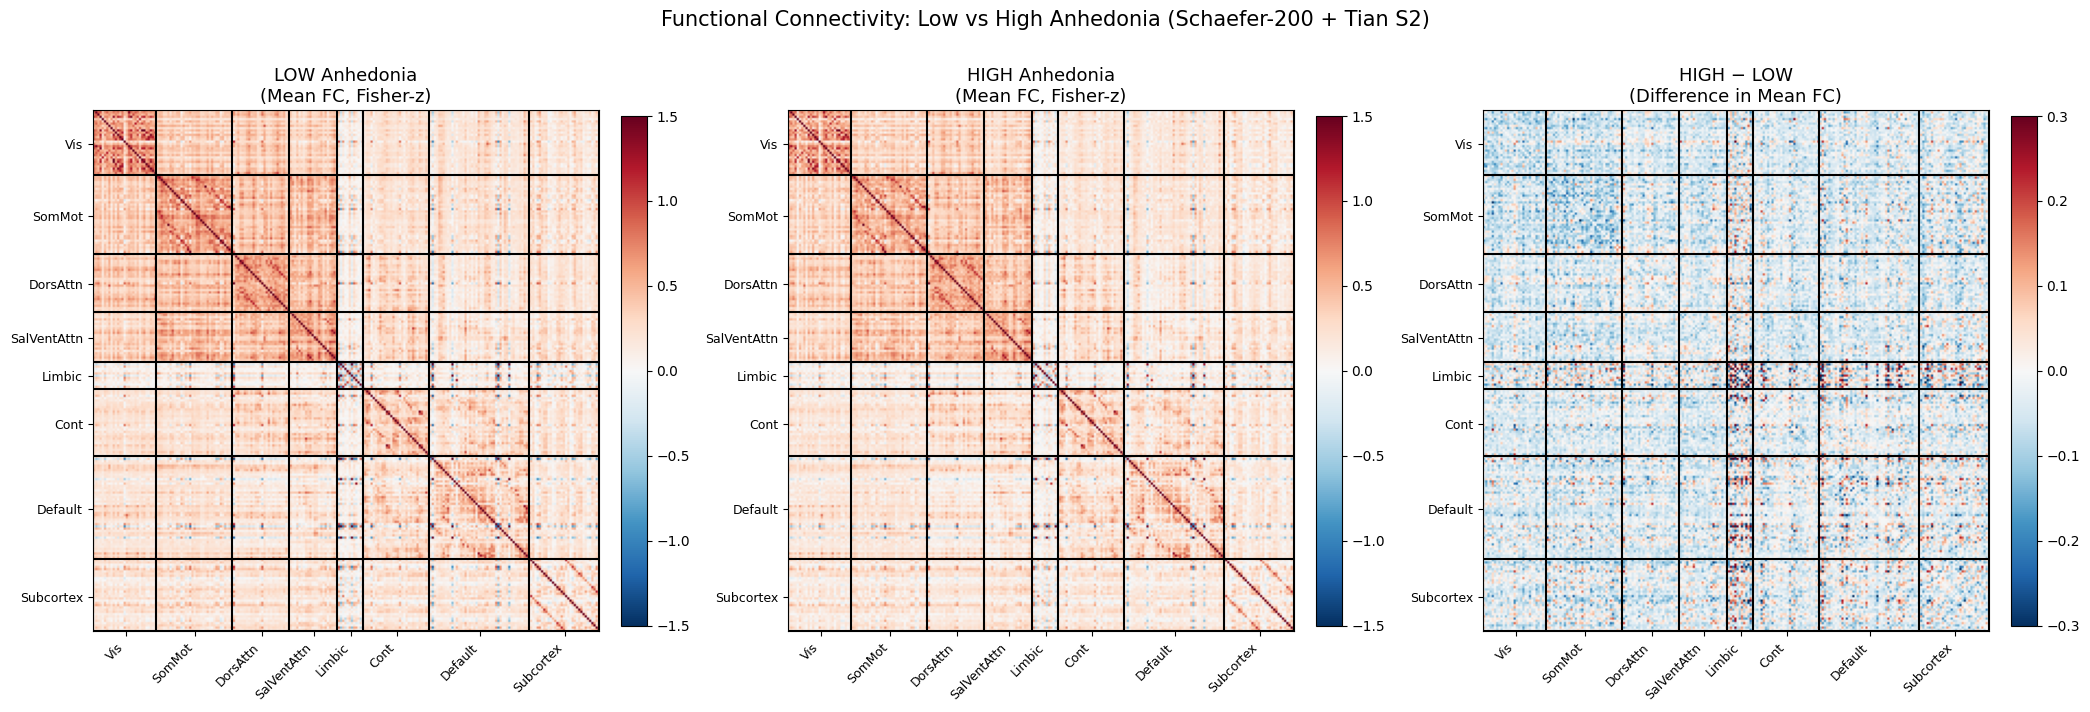

In [ ]:
# %% Figure: Group-average FC matrices + difference
vmax_fc = 1.5   # z-score range for mean FC
vmax_diff = 0.3  # z-score range for difference

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

data_to_plot = [
    (mean_fc_low_z,  'LOW Anhedonia\n(Mean FC, Fisher-z)', 'RdBu_r', vmax_fc),
    (mean_fc_high_z, 'HIGH Anhedonia\n(Mean FC, Fisher-z)', 'RdBu_r', vmax_fc),
    (diff_fc_z,      'HIGH − LOW\n(Difference in Mean FC)', 'RdBu_r', vmax_diff),
]

for ax, (mat, title, cmap, vmax) in zip(axes, data_to_plot):
    reordered = mat[np.ix_(roi_order_232, roi_order_232)]
    im = ax.imshow(reordered, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    draw_network_borders(ax, network_indices, display_order)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Functional Connectivity: Low vs High Anhedonia (Schaefer-200 + Tian S2)', fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

---
## Group comparison: covariate-adjusted OLS (mirrors the trophic-coherence notebooks)

Everything below recomputes, **on the empirical FC matrices**, the same families of group
contrasts used for the GEC / trophic-level measures in `payman_post_analyses_CLEAN.ipynb`
and `frontostriatal_connectivity_OLS.ipynb`, under the identical design

> `metric ~ anhedonia_group + Age + Sex + is_patient`

plus the two sensitivity models (patients-only; patients + broad-Dx) and BH-FDR within each
family. Reference levels: **LOW** anhedonia, **Female**, **Healthy Control**.

Because FC is **symmetric and edge-based**, the directional trophic measures are mapped as:

| trophic measure (directed) | FC analog (undirected) |
|---|---|
| regional / ROI trophic *level* (nodal) | **nodal FC strength** = mean FC of a region to the rest of the brain |
| compartment / boundary *flow asymmetry* (directional) | **mean block FC** across the boundary (single value; no top-down/bottom-up arms) |
| directed PFC→striatum *edges* | **mean undirected FC** between the ROI pair |

The six families below correspond one-to-one to the trophic notebook:
regional (Manhattan) · compartment cortex/subcortex + boundary · Yeo-7 networks ·
7 reward ROIs · PFC/striatum + boundary · 6 reward edges.

In [ ]:
# %% Demographics + covariate frame (same source / recoding as the trophic OLS notebooks)
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

demos = pd.read_excel(
    '/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/my_analysis/trophic_coherence_analysis/data/demos_payman.xls',
    header=1
)
demos['Age_clean']  = demos['Age'].replace(999, np.nan)
demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)

# Broad diagnostic-category mapping (identical to the trophic notebooks)
dx_map = {
    'MDD': 'Mood', 'BP1': 'Mood', 'BP2': 'Mood',
    'Dysthymia': 'Mood', 'Other Mood Dis': 'Mood',
    'GAD': 'Anxiety_Trauma', 'PTSD': 'Anxiety_Trauma',
    'SAD': 'Anxiety_Trauma', 'Other Anxiety': 'Anxiety_Trauma',
    'SZ': 'Other', 'SZA': 'Other', 'OCD': 'Other', 'SUD': 'Other',
    'ADHD': 'Other', 'ED': 'Other',
}
demos['Dx_label'] = demos['Primary_Dx_Payman'].replace(999, 'HC').astype(str).str.strip()
demos['Dx_broad'] = demos['Dx_label'].map(dx_map)

# --- Compartment index sets (0-based) ---
cortical_idx    = np.arange(32, 232)
subcortical_idx = np.arange(0, 32)

# --- Reward compartments (reuse reward_rois defined earlier in this notebook) ---
pfc_idx      = reward_rois['OFC'] + reward_rois['mPFC/vmPFC'] + reward_rois['ACC'] + reward_rois['dlPFC']
striatum_idx = reward_rois['NAc'] + reward_rois['Caudate'] + reward_rois['Putamen']

# --- Six theory-driven reward edges (same ROI sets as frontostriatal_connectivity_OLS.ipynb) ---
# FC is symmetric, so each "edge" is a single undirected mean-FC value.
NAc_idx  = [8, 9, 24, 25]
aPUT_idx = [12, 28]          # anterior putamen only (matches the directed-edge notebook)
EDGES = {
    'vmPFC_NAc':  (reward_rois['mPFC/vmPFC'], NAc_idx),
    'OFC_NAc':    (reward_rois['OFC'],        NAc_idx),
    'ACC_NAc':    (reward_rois['ACC'],        NAc_idx),
    'dlPFC_NAc':  (reward_rois['dlPFC'],      NAc_idx),
    'vmPFC_aPUT': (reward_rois['mPFC/vmPFC'], aPUT_idx),
    'ACC_aPUT':   (reward_rois['ACC'],        aPUT_idx),
}
EDGE_NAMES = list(EDGES.keys())

print('cortex', len(cortical_idx), '| subcortex', len(subcortical_idx))
print('PFC', len(pfc_idx), '| striatum', len(striatum_idx))
print('edges:', EDGE_NAMES)

cortex 200 | subcortex 32
PFC 49 | striatum 12
edges: ['vmPFC_NAc', 'OFC_NAc', 'ACC_NAc', 'dlPFC_NAc', 'vmPFC_aPUT', 'ACC_aPUT']


/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_93256/940556579.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demos['Age_clean']  = demos['Age'].replace(999, np.nan)
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_93256/940556579.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  demos['is_patient'] = demos['Primary_Dx_Payman'].apply(lambda x: 0 if x == 999 else 1)
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_93256/940556579.py:23: PerformanceWarning: DataFrame is highly fragmented.  

In [ ]:
# %% Per-subject FC metrics: nodal strength + block / edge mean FC (computed on Fisher-z FC)
# Nodal FC strength = mean Fisher-z FC of a region to all OTHER regions (self excluded).

def nodal_strength(fc_group):
    """fc_group: (N, 232, 232) Fisher-z. Returns (N, 232) mean off-diagonal connectivity."""
    g = fc_group.astype(float).copy()
    d = np.arange(g.shape[1])
    g[:, d, d] = np.nan
    return np.nanmean(g, axis=2)

strength_LOW  = nodal_strength(fc_low_z)    # (139, 232)
strength_HIGH = nodal_strength(fc_high_z)   # (71,  232)

def _within(fc, idx):
    sub = fc[np.ix_(idx, idx)]
    m = ~np.eye(len(idx), dtype=bool)
    return sub[m].mean()

def _cross(fc, a, b):
    return fc[np.ix_(a, b)].mean()

def group_metrics(fc_group, strength, ids, label):
    rows = []
    for s in range(fc_group.shape[0]):
        fc = fc_group[s]
        row = {
            'subjectkey': ids[s],
            'anhedonia_group': label,
            # --- compartment block FC ---
            'fc_within_cortex':    _within(fc, cortical_idx),
            'fc_within_subcortex': _within(fc, subcortical_idx),
            'fc_cortex_subcortex': _cross(fc, cortical_idx, subcortical_idx),   # boundary
            # --- reward block FC ---
            'fc_within_pfc':       _within(fc, pfc_idx),
            'fc_within_striatum':  _within(fc, striatum_idx),
            'fc_pfc_striatum':     _cross(fc, pfc_idx, striatum_idx),           # boundary
            # --- nodal-strength compartment means ---
            'strength_cortex':     strength[s, cortical_idx].mean(),
            'strength_subcortex':  strength[s, subcortical_idx].mean(),
            'strength_pfc':        strength[s, pfc_idx].mean(),
            'strength_striatum':   strength[s, striatum_idx].mean(),
        }
        row['strength_cx_gap'] = row['strength_cortex'] - row['strength_subcortex']
        row['strength_fs_gap'] = row['strength_pfc']    - row['strength_striatum']
        # per reward-ROI nodal strength
        for roi in roi_order:
            row[f'strength_{roi.replace("/", "_")}'] = strength[s, reward_rois[roi]].mean()
        # per Yeo-network + subcortex nodal strength
        for net in display_order:
            row[f'strength_net_{net}'] = strength[s, network_indices[net]].mean()
        # six undirected reward edges
        for name, (cidx, sidx) in EDGES.items():
            row[f'edge_{name}'] = _cross(fc, cidx, sidx)
        rows.append(row)
    return pd.DataFrame(rows)

fc_metrics = pd.concat([
    group_metrics(fc_low_z,  strength_LOW,  ids_low,  'LOW'),
    group_metrics(fc_high_z, strength_HIGH, ids_high, 'HIGH'),
], ignore_index=True)

# Merge demographics + recode reference levels (LOW / Female / HC)
fcdf = fc_metrics.merge(
    demos[['subjectkey', 'Age_clean', 'sex', 'is_patient', 'Dx_broad']],
    on='subjectkey', how='left'
)
fcdf['sex'] = fcdf['sex'].replace('O', np.nan)
fcdf['anhedonia_group'] = pd.Categorical(fcdf['anhedonia_group'], categories=['LOW', 'HIGH'])
fcdf['sex']             = pd.Categorical(fcdf['sex'],             categories=['F', 'M'])
fcdf['Dx_broad']        = pd.Categorical(fcdf['Dx_broad'], categories=['Mood', 'Anxiety_Trauma', 'Other'])

ROI_STRENGTH_COLS = [f'strength_{r.replace("/", "_")}' for r in roi_order]
NET_STRENGTH_COLS = [f'strength_net_{n}' for n in display_order]
EDGE_COLS         = [f'edge_{e}' for e in EDGE_NAMES]

print('fcdf:', fcdf.shape)
print(fcdf[['subjectkey', 'anhedonia_group', 'fc_cortex_subcortex', 'fc_pfc_striatum']].head())

fcdf: (210, 39)
         subjectkey anhedonia_group  fc_cortex_subcortex  fc_pfc_striatum
0  NDAR_INVCP169JDZ             LOW             0.298161         0.334377
1  NDAR_INVZR981ALE             LOW             0.086342         0.109654
2  NDAR_INVWJ892FLH             LOW             0.109101         0.094656
3  NDAR_INVWE937RD6             LOW             0.112646         0.189285
4  NDAR_INVAG900RVD             LOW             0.147372         0.158428


In [ ]:
# %% OLS helpers: 3 models (full / patients / patients+broad-Dx) + BH-FDR, mirroring the trophic notebooks
G = 'anhedonia_group[T.HIGH]'

def run_three(outcome, data):
    res_full = smf.ols(f'{outcome} ~ anhedonia_group + Age_clean + sex + is_patient', data=data).fit()
    dfp      = data[data['is_patient'] == 1]
    res_pat  = smf.ols(f'{outcome} ~ anhedonia_group + Age_clean + sex', data=dfp).fit()
    res_dx   = smf.ols(f'{outcome} ~ anhedonia_group + Age_clean + sex + Dx_broad',
                       data=dfp.dropna(subset=['Dx_broad'])).fit()
    ci_lo, ci_hi = res_full.conf_int().loc[G]
    return {
        'outcome': outcome,
        'beta_full': res_full.params[G], 'p_full': res_full.pvalues[G],
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'R2_full': res_full.rsquared,
        'beta_pat':  res_pat.params[G],  'p_pat':  res_pat.pvalues[G],
        'beta_dx':   res_dx.params[G],   'p_dx':   res_dx.pvalues[G],
        'N_full': int(res_full.nobs), 'N_pat': int(res_pat.nobs), 'N_dx': int(res_dx.nobs),
    }

def run_family(outcomes, data, title, fdr=True):
    res = pd.DataFrame([run_three(o, data) for o in outcomes])
    if fdr:
        for col in ['p_full', 'p_pat', 'p_dx']:
            res[col + '_FDR'] = multipletests(res[col], method='fdr_bh')[1]
    print('=' * 86)
    print(title)
    print('=' * 86)
    if fdr:
        print(f'{"outcome":<26}{"beta":>11}{"p_full":>9}{"q_full":>9}{"p_pat":>9}{"p_dx":>9}')
        print('-' * 86)
        for _, r in res.iterrows():
            sig = '*' if r['p_full_FDR'] < 0.05 else ' '
            print(f'{r["outcome"]:<26}{r["beta_full"]:>+11.4f}{r["p_full"]:>9.4f}'
                  f'{r["p_full_FDR"]:>9.4f}{r["p_pat"]:>9.4f}{r["p_dx"]:>9.4f} {sig}')
    else:
        print(f'{"outcome":<26}{"beta":>11}{"95% CI":>24}{"p_full":>9}{"p_pat":>9}{"p_dx":>9}')
        print('-' * 86)
        for _, r in res.iterrows():
            sig = '*' if r['p_full'] < 0.05 else ' '
            ci = f'[{r["ci_lo"]:+.4f}, {r["ci_hi"]:+.4f}]'
            print(f'{r["outcome"]:<26}{r["beta_full"]:>+11.4f}{ci:>24}{r["p_full"]:>9.4f}'
                  f'{r["p_pat"]:>9.4f}{r["p_dx"]:>9.4f} {sig}')
    print('-' * 86)
    print(f'N: full={res["N_full"].iloc[0]}, patients={res["N_pat"].iloc[0]}, patients+Dx={res["N_dx"].iloc[0]}'
          f'   ( * = full-model {"q" if fdr else "p"} < 0.05 )')
    return res

### Family 1 — Compartment FC: cortex / subcortex / boundary

FC analog of the cortex/subcortex mean trophic levels, the cortex−subcortex gap, and the
cortico-subcortical flow-asymmetry boundary. `fc_cortex_subcortex` (mean cross-block FC) is
the undirected counterpart of the directed boundary flow. Reported uncorrected (primary
single tests, as in the trophic notebook).

In [ ]:
# %% Family 1 — Compartment FC (cortex / subcortex / boundary) + nodal-strength gap
comp_outcomes = ['fc_within_cortex', 'fc_within_subcortex', 'fc_cortex_subcortex',
                 'strength_cortex', 'strength_subcortex', 'strength_cx_gap']
res_comp = run_family(comp_outcomes, fcdf,
                      'COMPARTMENT FC  —  cortex / subcortex / cortex<->subcortex boundary',
                      fdr=False)

COMPARTMENT FC  —  cortex / subcortex / cortex<->subcortex boundary
outcome                          beta                  95% CI   p_full    p_pat     p_dx
--------------------------------------------------------------------------------------
fc_within_cortex              -0.0158      [-0.0510, +0.0194]   0.3772   0.4375   0.3893  
fc_within_subcortex           -0.0159      [-0.0434, +0.0116]   0.2564   0.4508   0.4739  
fc_cortex_subcortex           -0.0165      [-0.0406, +0.0076]   0.1777   0.3678   0.3756  
strength_cortex               -0.0159      [-0.0490, +0.0172]   0.3454   0.4238   0.3816  
strength_subcortex            -0.0164      [-0.0405, +0.0076]   0.1787   0.3691   0.3789  
strength_cx_gap               +0.0006      [-0.0176, +0.0187]   0.9522   0.7742   0.6445  
--------------------------------------------------------------------------------------
N: full=206, patients=125, patients+Dx=125   ( * = full-model p < 0.05 )


### Family 2 — Regional FC strength (Manhattan + BH-FDR)

FC analog of the per-region trophic-level Manhattan plot (Fig 3a): each of the 232 regions
tested with the same per-region covariate-adjusted OLS, FDR-corrected across regions.

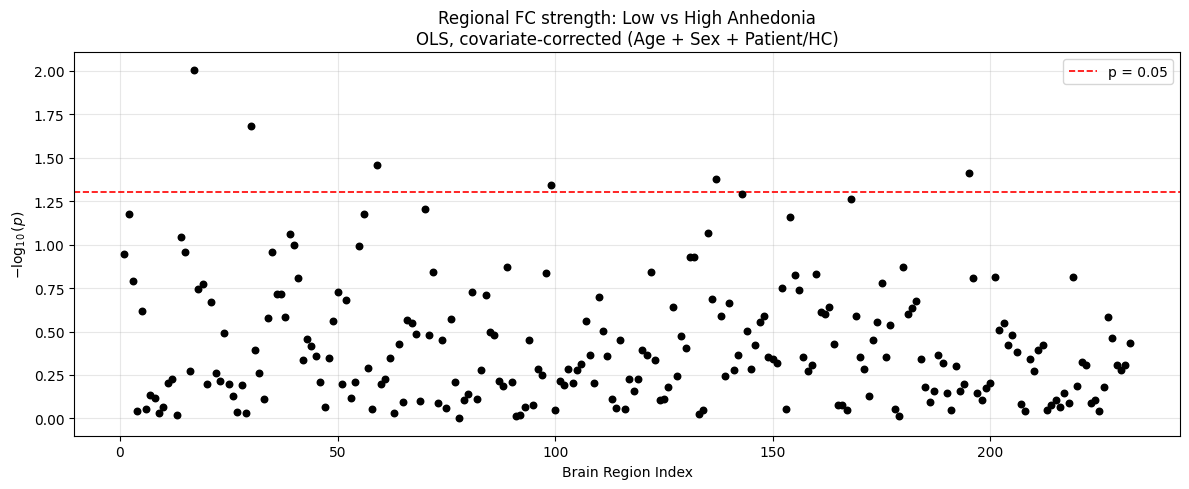

Regional FC strength OLS  (N per fit = 206)
  uncorrected p < 0.05 : 6/232
  BH-FDR      q < 0.05 : 0/232


In [ ]:
# %% Family 2 — Regional FC strength (per-region OLS + BH-FDR, Manhattan plot)
import matplotlib.pyplot as plt
N_regions = strength_LOW.shape[1]

base = pd.concat([
    pd.DataFrame({'subjectkey': ids_low,  'anhedonia_group': 'LOW',  'row': np.arange(len(ids_low)),  'grp': 'LOW'}),
    pd.DataFrame({'subjectkey': ids_high, 'anhedonia_group': 'HIGH', 'row': np.arange(len(ids_high)), 'grp': 'HIGH'}),
], ignore_index=True).merge(demos[['subjectkey', 'Age_clean', 'sex', 'is_patient']], on='subjectkey', how='left')
base['sex'] = base['sex'].replace('O', np.nan)
base['anhedonia_group'] = pd.Categorical(base['anhedonia_group'], categories=['LOW', 'HIGH'])
base['sex']             = pd.Categorical(base['sex'],             categories=['F', 'M'])
low_rows  = base.index[base['grp'] == 'LOW'];  high_rows = base.index[base['grp'] == 'HIGH']
low_src   = base.loc[low_rows, 'row'].to_numpy(); high_src = base.loc[high_rows, 'row'].to_numpy()

p_values = np.full(N_regions, np.nan); betas = np.full(N_regions, np.nan)
for i in range(N_regions):
    y = np.empty(len(base))
    y[low_rows]  = strength_LOW[low_src,  i]
    y[high_rows] = strength_HIGH[high_src, i]
    base['y'] = y
    res = smf.ols('y ~ anhedonia_group + Age_clean + sex + is_patient', data=base).fit()
    betas[i] = res.params[G]; p_values[i] = res.pvalues[G]

reject_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
neg_log_p = -np.log10(p_values)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, N_regions + 1)
ax.scatter(x, neg_log_p, s=22, c='k', zorder=3)
if np.any(reject_fdr):
    ax.scatter(x[reject_fdr], neg_log_p[reject_fdr], s=36, c='blue',
               edgecolors='white', linewidths=0.5, zorder=4, label='FDR sig.')
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=1.2, label='p = 0.05')
ax.set_xlabel('Brain Region Index'); ax.set_ylabel(r'$-\log_{10}(p)$')
ax.set_title('Regional FC strength: Low vs High Anhedonia\nOLS, covariate-corrected (Age + Sex + Patient/HC)')
ax.legend(loc='best'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'Regional FC strength OLS  (N per fit = {int(res.nobs)})')
print(f'  uncorrected p < 0.05 : {int(np.sum(p_values < 0.05))}/{N_regions}')
print(f'  BH-FDR      q < 0.05 : {int(np.sum(reject_fdr))}/{N_regions}')
for idx in np.where(reject_fdr)[0]:
    d = 'HIGH>LOW' if betas[idx] > 0 else 'HIGH<LOW'
    print(f'  region {idx+1:3d}  {region_labels[idx]:<34} beta={betas[idx]:+.4f} ({d})  q={p_fdr[idx]:.4g}')

### Family 3 — Yeo-7 networks + subcortex FC strength (OLS + BH-FDR)

FC analog of the network-level trophic-level analysis (mean nodal strength within each of
the seven Yeo networks and the subcortex; FDR across the 8).

In [ ]:
# %% Family 3 — Yeo-7 networks + subcortex FC strength (OLS + BH-FDR)
res_net = run_family(NET_STRENGTH_COLS, fcdf,
                     'NETWORK FC STRENGTH  (Yeo-7 + Subcortex)', fdr=True)

NETWORK FC STRENGTH  (Yeo-7 + Subcortex)
outcome                          beta   p_full   q_full    p_pat     p_dx
--------------------------------------------------------------------------------------
strength_net_Vis              -0.0234   0.2076   0.5026   0.3419   0.2768  
strength_net_SomMot           -0.0218   0.2913   0.5026   0.3353   0.2960  
strength_net_DorsAttn         -0.0148   0.3960   0.5026   0.5910   0.5282  
strength_net_SalVentAttn      -0.0137   0.4876   0.5026   0.4805   0.4554  
strength_net_Limbic           -0.0114   0.2050   0.5026   0.5248   0.5264  
strength_net_Cont             -0.0135   0.4125   0.5026   0.5046   0.4842  
strength_net_Default          -0.0111   0.5026   0.5026   0.4934   0.4553  
strength_net_Subcortex        -0.0164   0.1787   0.5026   0.3691   0.3789  
--------------------------------------------------------------------------------------
N: full=206, patients=125, patients+Dx=125   ( * = full-model q < 0.05 )


### Family 4 — Reward-circuit ROI FC strength (OLS + BH-FDR)

FC analog of the 7 reward-ROI trophic-level analysis (Fig 4a): nodal FC strength of each
reward ROI, FDR across the 7.

REWARD-ROI FC STRENGTH  (NAc/Caudate/Putamen/OFC/mPFC-vmPFC/ACC/dlPFC)
outcome                          beta   p_full   q_full    p_pat     p_dx
--------------------------------------------------------------------------------------
strength_NAc                  +0.0012   0.9384   0.9384   0.8323   0.7712  
strength_Caudate              -0.0180   0.3106   0.6642   0.5713   0.5968  
strength_Putamen              -0.0220   0.2650   0.6642   0.4553   0.5060  
strength_OFC                  -0.0060   0.5526   0.6671   0.6951   0.7061  
strength_mPFC_vmPFC           -0.0094   0.5718   0.6671   0.4558   0.4210  
strength_ACC                  -0.0173   0.3760   0.6642   0.4491   0.4248  
strength_dlPFC                -0.0156   0.3795   0.6642   0.4828   0.4399  
--------------------------------------------------------------------------------------
N: full=206, patients=125, patients+Dx=125   ( * = full-model q < 0.05 )


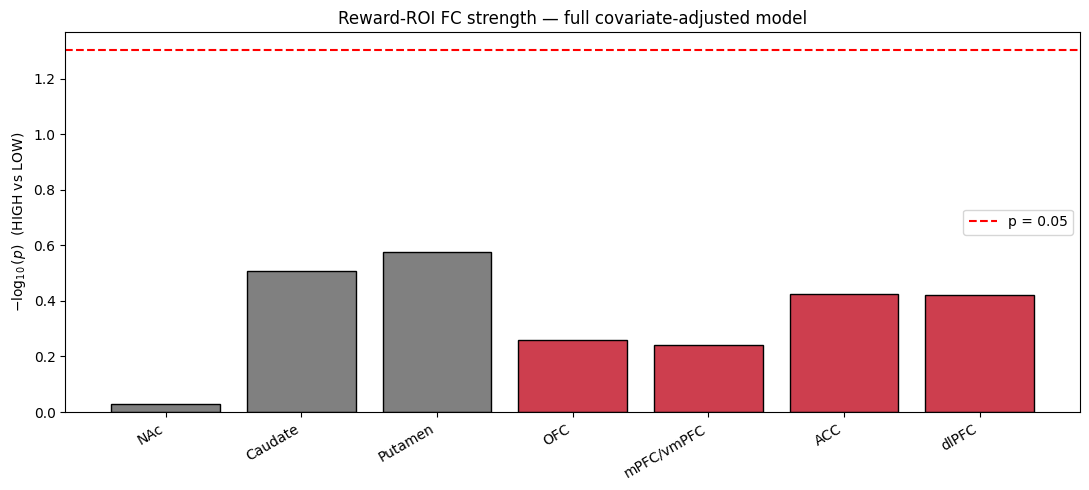

In [ ]:
# %% Family 4 — Reward-circuit ROI FC strength (OLS + BH-FDR)
res_roi = run_family(ROI_STRENGTH_COLS, fcdf,
                     'REWARD-ROI FC STRENGTH  (NAc/Caudate/Putamen/OFC/mPFC-vmPFC/ACC/dlPFC)',
                     fdr=True)

import matplotlib.pyplot as plt
xx  = np.arange(len(roi_order))
nlp = -np.log10(res_roi['p_full'].to_numpy())
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(xx, nlp, color=['#808080'] * 3 + ['#CD3E4E'] * 4, edgecolor='k')
ax.axhline(-np.log10(0.05), color='red', ls='--', label='p = 0.05')
ax.set_xticks(xx); ax.set_xticklabels(roi_order, rotation=30, ha='right')
ax.set_ylabel(r'$-\log_{10}(p)$  (HIGH vs LOW)')
ax.set_title('Reward-ROI FC strength — full covariate-adjusted model')
ax.legend(); plt.tight_layout(); plt.show()

### Family 5 — Reward compartment FC: PFC / striatum / boundary

FC analog of the PFC/striatum mean trophic levels, the PFC−striatum gap, and the
frontostriatal flow-asymmetry boundary. Reported uncorrected (primary single tests).

In [ ]:
# %% Family 5 — Reward compartment FC (PFC / striatum / boundary) + nodal-strength gap
fs_outcomes = ['fc_within_pfc', 'fc_within_striatum', 'fc_pfc_striatum',
               'strength_pfc', 'strength_striatum', 'strength_fs_gap']
res_fs = run_family(fs_outcomes, fcdf,
                    'REWARD COMPARTMENT FC  —  PFC / striatum / PFC<->striatum boundary',
                    fdr=False)

REWARD COMPARTMENT FC  —  PFC / striatum / PFC<->striatum boundary
outcome                          beta                  95% CI   p_full    p_pat     p_dx
--------------------------------------------------------------------------------------
fc_within_pfc                 -0.0114      [-0.0435, +0.0206]   0.4827   0.4407   0.4307  
fc_within_striatum            +0.0002      [-0.0536, +0.0541]   0.9930   0.8239   0.7242  
fc_pfc_striatum               -0.0077      [-0.0366, +0.0212]   0.6001   0.9740   0.9742  
strength_pfc                  -0.0121      [-0.0435, +0.0192]   0.4466   0.4522   0.4198  
strength_striatum             -0.0130      [-0.0427, +0.0168]   0.3922   0.6330   0.6882  
strength_fs_gap               +0.0008      [-0.0242, +0.0259]   0.9485   0.6759   0.5478  
--------------------------------------------------------------------------------------
N: full=206, patients=125, patients+Dx=125   ( * = full-model p < 0.05 )


### Family 6 — Six frontostriatal reward edges (undirected FC; OLS + BH-FDR)

FC analog of the six directed PFC→striatum edges (incl. the dlPFC→NAc standout). FC is
symmetric, so each edge is a single undirected mean-FC value; FDR across the 6.

In [ ]:
# %% Family 6 — Six frontostriatal reward edges (undirected mean FC; OLS + BH-FDR)
res_edge = run_family(EDGE_COLS, fcdf,
                      'FRONTOSTRIATAL REWARD EDGES  (undirected FC)', fdr=True)

FRONTOSTRIATAL REWARD EDGES  (undirected FC)
outcome                          beta   p_full   q_full    p_pat     p_dx
--------------------------------------------------------------------------------------
edge_vmPFC_NAc                +0.0110   0.6265   0.9563   0.4501   0.3987  
edge_OFC_NAc                  -0.0004   0.9891   0.9944   0.8914   0.8838  
edge_ACC_NAc                  +0.0113   0.6375   0.9563   0.5870   0.5315  
edge_dlPFC_NAc                -0.0002   0.9944   0.9944   0.5876   0.6068  
edge_vmPFC_aPUT               -0.0196   0.4100   0.9563   0.9197   0.9257  
edge_ACC_aPUT                 -0.0159   0.6171   0.9563   0.9520   0.9951  
--------------------------------------------------------------------------------------
N: full=206, patients=125, patients+Dx=125   ( * = full-model q < 0.05 )


### Severity association (SHAPS)

FC analog of the dimensional severity analysis: pooled correlation of the FC boundary
measures and the six reward edges with SHAPS total (uncorrected, as in the trophic notebook).

In [ ]:
# %% Severity: pooled correlation of FC boundary / edge measures with SHAPS total
from scipy.stats import pearsonr, spearmanr

shaps_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_shaps01.csv')
shaps_items['shaps_total'] = shaps_items.iloc[:, 1:].sum(axis=1)
id_col = shaps_items.columns[0]
shaps  = shaps_items[[id_col, 'shaps_total']].rename(columns={id_col: 'subjectkey'})

sev_cols = ['fc_cortex_subcortex', 'fc_pfc_striatum'] + EDGE_COLS
dcorr = fcdf[['subjectkey'] + sev_cols].merge(shaps, on='subjectkey', how='inner')
print(f'merged n = {len(dcorr)}\n')
print(f'{"measure":<22}{"n":>5}{"Pearson r":>12}{"p":>9}{"Spearman":>11}{"p":>9}')
print('-' * 68)
for c in sev_cols:
    sub = dcorr[[c, 'shaps_total']].dropna()
    rp, pp = pearsonr(sub[c], sub['shaps_total'])
    rs, ps = spearmanr(sub[c], sub['shaps_total'])
    flag = '*' if pp < 0.05 else ' '
    print(f'{c:<22}{len(sub):>5}{rp:>+12.3f}{pp:>9.4f}{rs:>+11.3f}{ps:>9.4f} {flag}')

merged n = 210

measure                   n   Pearson r        p   Spearman        p
--------------------------------------------------------------------
fc_cortex_subcortex     210      -0.178   0.0096     -0.151   0.0285 *
fc_pfc_striatum         210      -0.132   0.0562     -0.126   0.0687  
edge_vmPFC_NAc          210      -0.074   0.2873     -0.058   0.4058  
edge_OFC_NAc            210      -0.039   0.5729     -0.077   0.2680  
edge_ACC_NAc            210      -0.117   0.0899     -0.081   0.2433  
edge_dlPFC_NAc          210      -0.085   0.2194     -0.106   0.1244  
edge_vmPFC_aPUT         210      -0.140   0.0431     -0.216   0.0016 *
edge_ACC_aPUT           210      -0.095   0.1710     -0.124   0.0723  


### Summary — does FC distinguish the groups?

In [ ]:
# %% Summary: FC group differences across all families (full covariate-adjusted model)
print('FC group-difference summary  (full model, HIGH vs LOW; Family-wise FDR where applicable)')
print('=' * 78)
print(f'  Compartment FC (6, uncorrected) : {int((res_comp["p_full"]<0.05).sum())}/6 at p<0.05')
print(f'  Regional FC strength (232)      : {int(np.sum(p_values<0.05))} at p<0.05, '
      f'{int(np.sum(reject_fdr))} survive FDR')
print(f'  Network FC strength (8)         : {int((res_net["p_full"]<0.05).sum())} at p<0.05, '
      f'{int((res_net["p_full_FDR"]<0.05).sum())} survive FDR')
print(f'  Reward-ROI FC strength (7)      : {int((res_roi["p_full"]<0.05).sum())} at p<0.05, '
      f'{int((res_roi["p_full_FDR"]<0.05).sum())} survive FDR')
print(f'  Reward compartment FC (6, unc.) : {int((res_fs["p_full"]<0.05).sum())}/6 at p<0.05')
print(f'  Frontostriatal edges (6)        : {int((res_edge["p_full"]<0.05).sum())} at p<0.05, '
      f'{int((res_edge["p_full_FDR"]<0.05).sum())} survive FDR')

FC group-difference summary  (full model, HIGH vs LOW; Family-wise FDR where applicable)
  Compartment FC (6, uncorrected) : 0/6 at p<0.05
  Regional FC strength (232)      : 6 at p<0.05, 0 survive FDR
  Network FC strength (8)         : 0 at p<0.05, 0 survive FDR
  Reward-ROI FC strength (7)      : 0 at p<0.05, 0 survive FDR
  Reward compartment FC (6, unc.) : 0/6 at p<0.05
  Frontostriatal edges (6)        : 0 at p<0.05, 0 survive FDR


### Supplementary Figure 2 — publication figure

Assembles the three FC panels that Supplementary Figure 2 of the manuscript needs, and writes `fig_s2.png` into the paper's `figures/` folder. Each panel is annotated with the matched directed result, so the FC-versus-directed contrast is readable without replotting the directed panels from the other two notebooks.

Run after Families 1, 2, 5 and 6 above (it uses `p_values`, `reject_fdr`, `res_comp`, `res_fs`, `res_edge` and `fcdf`).

In [ ]:
# %% Supplementary Figure 2 — FC control analysis (3-panel publication figure)
# Each panel is the undirected analogue of a directed result, annotated with that
# directed result so the contrast is readable without the directed panels beside it:
#   (a) per-region FC nodal strength      <-> Fig. 3a  (regional trophic levels)
#   (b) cortex-subcortex / PFC-striatum   <-> Figs 3e, 4b  (hierarchical gaps)
#   (c) six frontostriatal edges          <-> Supplementary Table 2  (directed edges)
# Requires, from earlier cells: p_values / betas / reject_fdr (Family 2),
# res_comp (Family 1), res_fs (Family 5), res_edge (Family 6), fcdf.

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

FIG_OUT = ('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/'
           'my_analysis/anhedonia_paper/figures/fig_s2.png')

C_LOW, C_HIGH = '#0173B2', '#DE8F05'          # colour-blind-safe pair
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11})


def _sgn(value, nd=4):
    """Signed number with a typographic minus, to match the annotated directed values."""
    return f'{value:+.{nd}f}'.replace('-', '−')


def _half_violin(ax, data, pos, color, width=0.34):
    """Kernel density on the right of `pos`, normalised to equal width."""
    kde = gaussian_kde(data)
    ys = np.linspace(data.min(), data.max(), 200)
    d = kde(ys)
    d = d / d.max() * width
    ax.fill_betweenx(ys, pos, pos + d, color=color, alpha=0.40, lw=0)
    ax.plot(pos + d, ys, color=color, lw=1.0)


def _raincloud(ax, values, pos, color, rng):
    """Half violin (right), box (centre), one dot per participant (left)."""
    data = np.asarray(values, dtype=float)
    data = data[np.isfinite(data)]
    _half_violin(ax, data, pos + 0.06, color)
    bp = ax.boxplot(data, positions=[pos - 0.03], widths=0.12,
                    showfliers=False, patch_artist=True, manage_ticks=False)
    for box in bp['boxes']:
        box.set(facecolor='white', edgecolor=color, lw=1.2)
    for key in ('whiskers', 'caps', 'medians'):
        for artist in bp[key]:
            artist.set(color=color, lw=1.2)
    jitter = rng.uniform(-0.055, 0.055, size=data.size)
    ax.scatter(pos - 0.22 + jitter, data, s=7, color=color, alpha=0.55,
               edgecolors='none', zorder=2)


rng = np.random.default_rng(0)
fig = plt.figure(figsize=(13, 14))
gs = gridspec.GridSpec(3, 1, height_ratios=[1.0, 1.15, 0.9], hspace=0.45)

# ---------------- (a) per-region FC nodal strength ----------------
ax_a = fig.add_subplot(gs[0])
xs = np.arange(1, len(p_values) + 1)
nlp = -np.log10(p_values)
ax_a.scatter(xs, nlp, s=18, c='0.35', edgecolors='none', zorder=3)
if np.any(reject_fdr):
    ax_a.scatter(xs[reject_fdr], nlp[reject_fdr], s=34, c=C_HIGH,
                 edgecolors='white', lw=0.5, zorder=4, label='survives FDR')
    ax_a.legend(loc='upper right', frameon=False)
ax_a.axhline(-np.log10(0.05), color='0.25', ls='--', lw=1.1)
ax_a.axvline(32.5, color='0.75', lw=0.9, ls=':')
ax_a.set_xlim(0, len(p_values) + 1)
_lo, _hi = ax_a.get_ylim()
ax_a.set_ylim(_lo, _hi + 0.12 * (_hi - _lo))
_top = ax_a.get_ylim()[1]
ax_a.text(16, _top, 'subcortex', ha='center', va='top', fontsize=9, color='0.45')
ax_a.text(133, _top, 'cortex', ha='center', va='top', fontsize=9, color='0.45')
ax_a.text(len(p_values), -np.log10(0.05), 'p = 0.05 ', va='bottom', ha='right',
          fontsize=9, color='0.25')
ax_a.set_xlabel('Region index')
ax_a.set_ylabel(r'$-\log_{10}(p)$')
_n_unc, _n_fdr = int((p_values < 0.05).sum()), int(reject_fdr.sum())
ax_a.set_title(
    f'Regional FC strength  —  {_n_unc}/232 uncorrected, {_n_fdr}/232 survive FDR\n'
    'directed trophic levels: 122/232 uncorrected, 29/232 survive FDR')
ax_a.grid(alpha=0.25)

# ---------------- (b) FC analogues of the two hierarchical gaps ----------------
gs_b = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.30)
gap_specs = [
    ('strength_cx_gap', res_comp, 'Cortex − subcortex FC strength gap',
     'directed trophic gap  β = −0.0230, p < 0.001'),
    ('strength_fs_gap', res_fs, 'PFC − striatum FC strength gap',
     'directed trophic gap  β = −0.0246, p < 0.001'),
]
ax_b_first = None
for j, (col, res_tbl, title, directed) in enumerate(gap_specs):
    ax = fig.add_subplot(gs_b[j])
    if ax_b_first is None:
        ax_b_first = ax
    row = res_tbl.loc[res_tbl['outcome'] == col].iloc[0]
    for k, (grp, colour) in enumerate((('LOW', C_LOW), ('HIGH', C_HIGH))):
        _raincloud(ax, fcdf.loc[fcdf['anhedonia_group'] == grp, col], k, colour, rng)
    ax.axhline(0, color='0.6', lw=0.9, ls='--')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Low\nanhedonia', 'High\nanhedonia'])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylabel('Fisher-z FC strength difference')
    ax.set_title(f'{title}\n'
                 f'FC  β = {_sgn(row["beta_full"])}, p = {row["p_full"]:.2f} (ns)\n'
                 f'{directed}')
    ax.grid(alpha=0.25, axis='y')

# ---------------- (c) six frontostriatal edges ----------------
ax_c = fig.add_subplot(gs[2])
EDGE_LABEL = {'vmPFC_NAc': 'vmPFC–NAc', 'OFC_NAc': 'OFC–NAc', 'ACC_NAc': 'ACC–NAc',
              'dlPFC_NAc': 'dlPFC–NAc', 'vmPFC_aPUT': 'vmPFC–aPUT', 'ACC_aPUT': 'ACC–aPUT'}
edges = res_edge.copy()
edges['label'] = (edges['outcome'].str.replace('edge_', '', regex=False)
                  .map(EDGE_LABEL))
edges = edges.iloc[::-1].reset_index(drop=True)      # first-listed edge on top
ypos = np.arange(len(edges))
ax_c.errorbar(edges['beta_full'], ypos,
              xerr=[edges['beta_full'] - edges['ci_lo'],
                    edges['ci_hi'] - edges['beta_full']],
              fmt='o', color='0.25', ecolor='0.55', capsize=3, ms=6, lw=1.2)
ax_c.axvline(0, color='0.6', lw=0.9, ls='--')
ax_c.set_yticks(ypos)
ax_c.set_yticklabels(edges['label'])
ax_c.set_ylim(-0.7, len(edges) - 0.3)
ax_c.set_xlabel('FC group difference (high − low anhedonia), Fisher-z  [95% CI]')
_span = edges['ci_hi'].max() - edges['ci_lo'].min()
_xtext = edges['ci_hi'].max() + 0.05 * _span
for i, row in edges.iterrows():
    ax_c.text(_xtext, i, f'p = {row["p_full"]:.2f}', va='center', ha='left',
              fontsize=9, color='0.35')
ax_c.set_xlim(right=_xtext + 0.17 * _span)
ax_c.set_title('Six frontostriatal reward edges  —  undirected FC, none differ between groups\n'
               'directed dlPFC→NAc  β = +0.0110, q = 0.005')
ax_c.grid(alpha=0.25, axis='x')

# ---------------- panel letters ----------------
for ax, letter in ((ax_a, 'a'), (ax_b_first, 'b'), (ax_c, 'c')):
    ax.text(-0.065, 1.10, letter, transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right')

plt.savefig(FIG_OUT, dpi=300, bbox_inches='tight')
plt.show()
print(f'Supplementary Figure 2 saved -> {FIG_OUT}')